,side,real_kpc,model_kpc,difference_kpc,relative_error_percent
0,left,218.668345,219.789411,1.121066,0.512679
1,right,227.634221,226.513155,-1.121066,-0.492486
2,mean,223.151283,223.151283,0.000000,0.000000


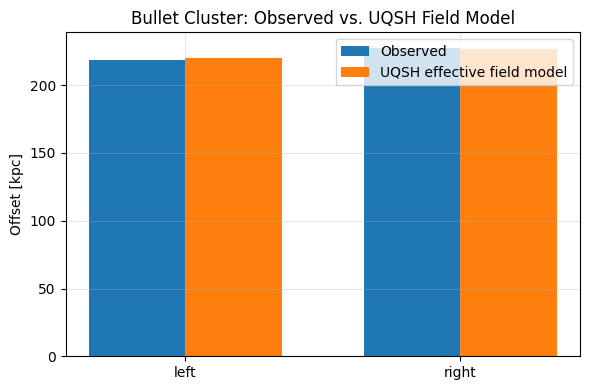

Summary:
Observed mean offset: 223.2 kpc
UQSH model mean offset: 223.2 kpc
Mean difference: 0.00 kpc

Interpretation:
The UQSH effective field model compares the observed gas-to-kappa offsets with the offsets expected from coherent field-anchor structures. The effective field term represents the combined contribution of time-averaged radiation-induced deformation, residual non-relaxed deformation, and nonlinear or saturation-related field organisation.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# CSV hochladen oder in /content/ ablegen
csv_path = "/content/bullet_cluster_comparison.csv"

df = pd.read_csv(csv_path)

# Erwartete Spalten:
# side, real_kpc, model_kpc

df["difference_kpc"] = df["model_kpc"] - df["real_kpc"]
df["relative_error_percent"] = 100 * df["difference_kpc"] / df["real_kpc"]

display(df)

# Nur left/right für Balkendiagramm
plot_df = df[df["side"].isin(["left", "right"])].copy()

labels = plot_df["side"].tolist()
real_vals = plot_df["real_kpc"].to_numpy()
model_vals = plot_df["model_kpc"].to_numpy()

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, real_vals, width, label="Observed")
plt.bar(x + width/2, model_vals, width, label="UQSH effective field model")

plt.ylabel("Offset [kpc]")
plt.title("Bullet Cluster: Observed vs. UQSH Field Model")
plt.xticks(x, labels)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_bullet_offsets.png", dpi=300, bbox_inches="tight")
plt.show()

# Mittelwerte
mean_real = df.loc[df["side"] == "mean", "real_kpc"].iloc[0]
mean_model = df.loc[df["side"] == "mean", "model_kpc"].iloc[0]

print("Summary:")
print(f"Observed mean offset: {mean_real:.1f} kpc")
print(f"UQSH model mean offset: {mean_model:.1f} kpc")
print(f"Mean difference: {mean_model - mean_real:.2f} kpc")

print("\nInterpretation:")
print(
    "The UQSH effective field model compares the observed gas-to-kappa "
    "offsets with the offsets expected from coherent field-anchor structures. "
    "The effective field term represents the combined contribution of "
    "time-averaged radiation-induced deformation, residual non-relaxed "
    "deformation, and nonlinear or saturation-related field organisation."
)